# Realistic Multi-Platform Advertising Simulation

Chain Sharing UCB with **estimated weights** (pooled arm2 + PAVA isotonic projection).

**Platforms** (ordered by decreasing arm gap δ):
| Platform | Arm 1 | Arm 2 | δ_true |
|---|---|---|---|
| Google Search | Top sponsored result | Third sponsored result | 0.018 |
| Facebook Feed | Pinned feed ad | Mid-feed ad | 0.011 |
| Instagram Stories | First story slot | Third story slot | 0.008 |
| YouTube Pre-roll | Non-skippable 5s ad | Skippable pre-roll ad | 0.006 |

**Weight estimation:** δ̂_i = x̄_i(arm1) − μ̂_base (pooled arm2), then PAVA projection to non-increasing order.  
Weights are estimated once after M0 warm-start pulls and held **fixed** for the entire UCB phase.

**Single run up to T = 5000; results recorded at T = 1000 / 2000 / 3000 / 4000 / 5000.**

In [1]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from IPython.display import display, Image
import pandas as pd

from realistic_simulation import (
    PLATFORMS,
    estimate_sharing_weights,
    wilcox_p,
)

## Platform Configuration

In [2]:
deltas_true = [p['arm1']['mu'] - p['arm2']['mu'] for p in PLATFORMS]

rows = []
for p, d in zip(PLATFORMS, deltas_true):
    rows.append({
        'Platform':  p['name'],
        'Arm 1':     p['arm1']['name'],
        'Arm 2':     p['arm2']['name'],
        'μ₁':        p['arm1']['mu'],
        'μ₂':        p['arm2']['mu'],
        'δ_true':    d,
    })
display(pd.DataFrame(rows).set_index('Platform'))

assert all(deltas_true[i] > deltas_true[i+1] for i in range(len(deltas_true)-1))
print('Delta strictly decreasing: OK')

,Arm 1,Arm 2,μ₁,μ₂,δ_true
Platform,,,,,
Google Search,Top sponsored result,Third sponsored result,0.055,0.037,0.018
Facebook Feed,Pinned feed ad,Mid-feed ad,0.047,0.036,0.011
Instagram Stories,First story slot,Third story slot,0.043,0.035,0.008
YouTube Pre-roll,Non-skippable 5s ad,Skippable pre-roll ad,0.039,0.033,0.006


Delta strictly decreasing: OK


## Horizon Sweep — single run T = 5000, checkpoints T = 1000 / 2000 / 3000 / 4000 / 5000

In [3]:
def run_horizon_sweep(platforms, T_max, M0, C, K_rep, rng, checkpoints):
    """
    Single simulation up to T_max.
    At each t in `checkpoints` records cumulative regret and MSE (arm-sum).
    Warm-start weights (pooled arm2 + PAVA) fixed after M0 pulls.
    Paired design: baseline and sharing share the same reward table.
    """
    checkpoints = sorted(checkpoints)
    K       = len(platforms)
    n_share = K - 1
    n_cp    = len(checkpoints)

    rb_cp  = np.zeros((K_rep, n_cp, K))        # regret baseline
    rs_cp  = np.zeros((K_rep, n_cp, K))        # regret sharing
    msb_cp = np.zeros((K_rep, n_cp, n_share))  # MSE arm-sum baseline
    mss_cp = np.zeros((K_rep, n_cp, n_share))  # MSE arm-sum sharing

    alphas_all    = np.zeros((K_rep, K))
    betas_all     = np.zeros((K_rep, K))
    delta_hat_all = np.zeros((K_rep, K))
    dt            = [p['arm1']['mu'] - p['arm2']['mu'] for p in platforms]

    for rep in range(K_rep):
        if rep % 200 == 0:
            print(f'  rep {rep}/{K_rep}')

        # Shared reward table
        table = []
        for i in range(K):
            row = {}
            for arm in [1, 2]:
                mu = platforms[i][f'arm{arm}']['mu']
                row[arm] = rng.binomial(1, mu, size=T_max + M0 + 5)
            table.append(row)

        # Warm start
        N  = [{1: 0, 2: 0} for _ in range(K)]
        S  = [{1: 0.0, 2: 0.0} for _ in range(K)]
        Ns = [{1: 0, 2: 0} for _ in range(K)]
        Ss = [{1: 0.0, 2: 0.0} for _ in range(K)]

        for i in range(K):
            for arm in [1, 2]:
                for _ in range(M0):
                    c = table[i][arm][N[i][arm]]
                    N[i][arm]  += 1;  S[i][arm]  += c
                    Ns[i][arm] += 1;  Ss[i][arm] += c

        # Estimate fixed weights (pooled arm2 + PAVA)
        alphas, betas, d_hat = estimate_sharing_weights(Ns, Ss, K)
        alphas_all[rep]    = alphas
        betas_all[rep]     = betas
        delta_hat_all[rep] = d_hat

        def xb(ns, ss, i, k):
            return ss[i][k] / ns[i][k] if ns[i][k] > 0 else 0.0

        regret_b = [0.0] * K
        regret_s = [0.0] * K
        cp_idx   = 0

        for t in range(1, T_max + 1):
            actions_b, actions_s = [], []
            for i in range(K):
                ucb_b = {k: xb(N,S,i,k) + C*np.sqrt(np.log(t)/N[i][k]) for k in [1,2]}
                actions_b.append(max(ucb_b, key=ucb_b.get))

                mean_s = ({k: xb(Ns,Ss,i,k) for k in [1,2]} if i == 0
                          else {k: alphas[i]*xb(Ns,Ss,i,k) + betas[i]*xb(Ns,Ss,i-1,k)
                               for k in [1,2]})
                ucb_s = {k: mean_s[k] + C*np.sqrt(np.log(t)/Ns[i][k]) for k in [1,2]}
                actions_s.append(max(ucb_s, key=ucb_s.get))

            for i in range(K):
                a_b = actions_b[i]; a_s = actions_s[i]
                c_b = table[i][a_b][N[i][a_b]]
                c_s = table[i][a_s][Ns[i][a_s]]
                N[i][a_b]  += 1; S[i][a_b]  += c_b
                Ns[i][a_s] += 1; Ss[i][a_s] += c_s
                regret_b[i] += platforms[i]['arm1']['mu'] - platforms[i][f'arm{a_b}']['mu']
                regret_s[i] += platforms[i]['arm1']['mu'] - platforms[i][f'arm{a_s}']['mu']

            if cp_idx < n_cp and t == checkpoints[cp_idx]:
                for i in range(K):
                    rb_cp[rep, cp_idx, i] = regret_b[i]
                    rs_cp[rep, cp_idx, i] = regret_s[i]
                for j, i in enumerate(range(1, K)):
                    mu1 = platforms[i]['arm1']['mu']
                    mu2 = platforms[i]['arm2']['mu']
                    e1b = xb(N,S,i,1);  e2b = xb(N,S,i,2)
                    e1s = alphas[i]*xb(Ns,Ss,i,1) + betas[i]*xb(Ns,Ss,i-1,1)
                    e2s = alphas[i]*xb(Ns,Ss,i,2) + betas[i]*xb(Ns,Ss,i-1,2)
                    msb_cp[rep, cp_idx, j] = (e1b-mu1)**2 + (e2b-mu2)**2
                    mss_cp[rep, cp_idx, j] = (e1s-mu1)**2 + (e2s-mu2)**2
                cp_idx += 1

    regret_wr    = np.zeros((n_cp, K))
    mse_wr       = np.zeros((n_cp, n_share))
    regret_base  = rb_cp.mean(axis=0)   # (n_cp, K)
    regret_share = rs_cp.mean(axis=0)
    mse_base     = msb_cp.mean(axis=0)  # (n_cp, n_share)
    mse_share    = mss_cp.mean(axis=0)

    for c in range(n_cp):
        for i in range(K):
            regret_wr[c,i] = np.mean(rs_cp[:,c,i] < rb_cp[:,c,i])
        for j in range(n_share):
            mse_wr[c,j] = np.mean(mss_cp[:,c,j] < msb_cp[:,c,j])

    return dict(
        checkpoints    = checkpoints,
        regret_wr      = regret_wr,
        mse_wr         = mse_wr,
        regret_base    = regret_base,
        regret_share   = regret_share,
        mse_base       = mse_base,
        mse_share      = mse_share,
        alphas_mean    = alphas_all.mean(axis=0),
        betas_mean     = betas_all.mean(axis=0),
        delta_hat_mean = delta_hat_all.mean(axis=0),
        deltas_true    = dt,
    )

In [4]:
CHECKPOINTS = [1000, 2000, 3000, 4000, 5000]
T_MAX = 5000
M0    = 100     # warm-start pulls per arm  (200 total per platform)
C     = 2.0
K_REP = 1000

print(f'T_max={T_MAX}, M0={M0} ({M0*2} warm pulls/platform), C={C}, K_rep={K_REP}')
print(f'Checkpoints: {CHECKPOINTS}\n')

sw = run_horizon_sweep(
    PLATFORMS, T_MAX, M0, C, K_REP,
    rng=np.random.default_rng(2026),
    checkpoints=CHECKPOINTS,
)
print('\nDone.')

T_max=5000, M0=100 (200 warm pulls/platform), C=2.0, K_rep=1000
Checkpoints: [1000, 2000, 3000, 4000, 5000]

  rep 0/1000
  rep 200/1000
  rep 400/1000
  rep 600/1000
  rep 800/1000

Done.


## Estimated Weights (mean across replications)
Pooled arm2 + PAVA — fixed after warm start, same weights apply at every checkpoint.

In [5]:
K = len(PLATFORMS)

rows_w = []
for i in range(K):
    rows_w.append({
        'Platform':    PLATFORMS[i]['name'],
        'δ_true':      sw['deltas_true'][i],
        'δ̂ (mean)':   sw['delta_hat_mean'][i],
        'δ̂ / δ_true': sw['delta_hat_mean'][i] / sw['deltas_true'][i],
        'α (mean)':    sw['alphas_mean'][i],
        'β (mean)':    sw['betas_mean'][i],
    })
df_w = pd.DataFrame(rows_w).set_index('Platform')
df_w = df_w.style.format({
    'δ_true':      '{:.4f}',
    'δ̂ (mean)':   '{:.4f}',
    'δ̂ / δ_true': '{:.2f}×',
    'α (mean)':    '{:.3f}',
    'β (mean)':    '{:.3f}',
})
display(df_w)

,δ_true,δ̂ (mean),δ̂ / δ_true,α (mean),β (mean)
Platform,,,,,
Google Search,0.0180,0.0272,1.51×,1.000,0.000
Facebook Feed,0.0110,0.0161,1.46×,0.636,0.364
Instagram Stories,0.0080,0.0105,1.31×,0.613,0.387
YouTube Pre-roll,0.0060,0.0053,0.89×,0.632,0.368


## Regret & MSE at Each Checkpoint

In [6]:
T_vals = sw['checkpoints']
rwr    = sw['regret_wr'] * 100
mwr    = sw['mse_wr']    * 100

for c, t in enumerate(T_vals):
    print(f'\n{"="*68}')
    print(f'  T = {t}')
    print(f'{"="*68}')
    print(f'{"Platform":<24} {"Base":>8}  {"Share":>8}  {"Decrease":>10}  {"Regret WR":>10}  {"MSE WR":>8}')
    print('-'*72)
    for i in range(K):
        dec    = sw['regret_base'][c,i] - sw['regret_share'][c,i]
        rw_str = '—' if i == 0 else f'{rwr[c,i]:.1f}%'
        j      = i - 1
        mw_str = '—' if i == 0 else f'{mwr[c,j]:.1f}%'
        anc    = '  [anchor]' if i == 0 else ''
        print(f"{PLATFORMS[i]['name']:<24} "
              f"{sw['regret_base'][c,i]:>8.3f}  "
              f"{sw['regret_share'][c,i]:>8.3f}  "
              f"{dec:>+10.4f}  "
              f"{rw_str:>10}  "
              f"{mw_str:>8}"
              f"{anc}")


  T = 1000
Platform                     Base     Share    Decrease   Regret WR    MSE WR
------------------------------------------------------------------------
Google Search               8.102     8.102     +0.0000           —         —  [anchor]
Facebook Feed               5.159     5.102     +0.0574       59.1%     70.7%
Instagram Stories           3.825     3.806     +0.0194       49.5%     71.6%
YouTube Pre-roll            2.899     2.899     +0.0001       43.8%     74.1%

  T = 2000
Platform                     Base     Share    Decrease   Regret WR    MSE WR
------------------------------------------------------------------------
Google Search              15.880    15.880     +0.0000           —         —  [anchor]
Facebook Feed              10.205    10.046     +0.1587       65.2%     65.3%
Instagram Stories           7.586     7.534     +0.0524       53.4%     72.7%
YouTube Pre-roll            5.763     5.750     +0.0127       47.2%     68.8%

  T = 3000
Platform          

## Win Rate vs Horizon — Summary Tables

In [7]:
rows_rwr, rows_mwr = [], []
for c, t in enumerate(T_vals):
    r = {'T': t}
    m = {'T': t}
    for i in range(1, K):
        r[PLATFORMS[i]['name']] = f'{rwr[c,i]:.1f}%'
    for j, i in enumerate(range(1, K)):
        m[PLATFORMS[i]['name']] = f'{mwr[c,j]:.1f}%'
    rows_rwr.append(r)
    rows_mwr.append(m)

print('Regret Win Rate')
display(pd.DataFrame(rows_rwr).set_index('T'))
print('\nMSE Win Rate (arm-sum)')
display(pd.DataFrame(rows_mwr).set_index('T'))

Regret Win Rate


,Facebook Feed,Instagram Stories,YouTube Pre-roll
T,,,
1000,59.1%,49.5%,43.8%
2000,65.2%,53.4%,47.2%
3000,70.4%,57.5%,48.6%
4000,73.3%,58.5%,52.6%
5000,76.8%,62.7%,55.5%



MSE Win Rate (arm-sum)


,Facebook Feed,Instagram Stories,YouTube Pre-roll
T,,,
1000,70.7%,71.6%,74.1%
2000,65.3%,72.7%,68.8%
3000,60.2%,70.8%,67.6%
4000,56.8%,70.8%,67.8%
5000,52.2%,64.5%,66.2%


## Win Rate vs Horizon — Visualisation

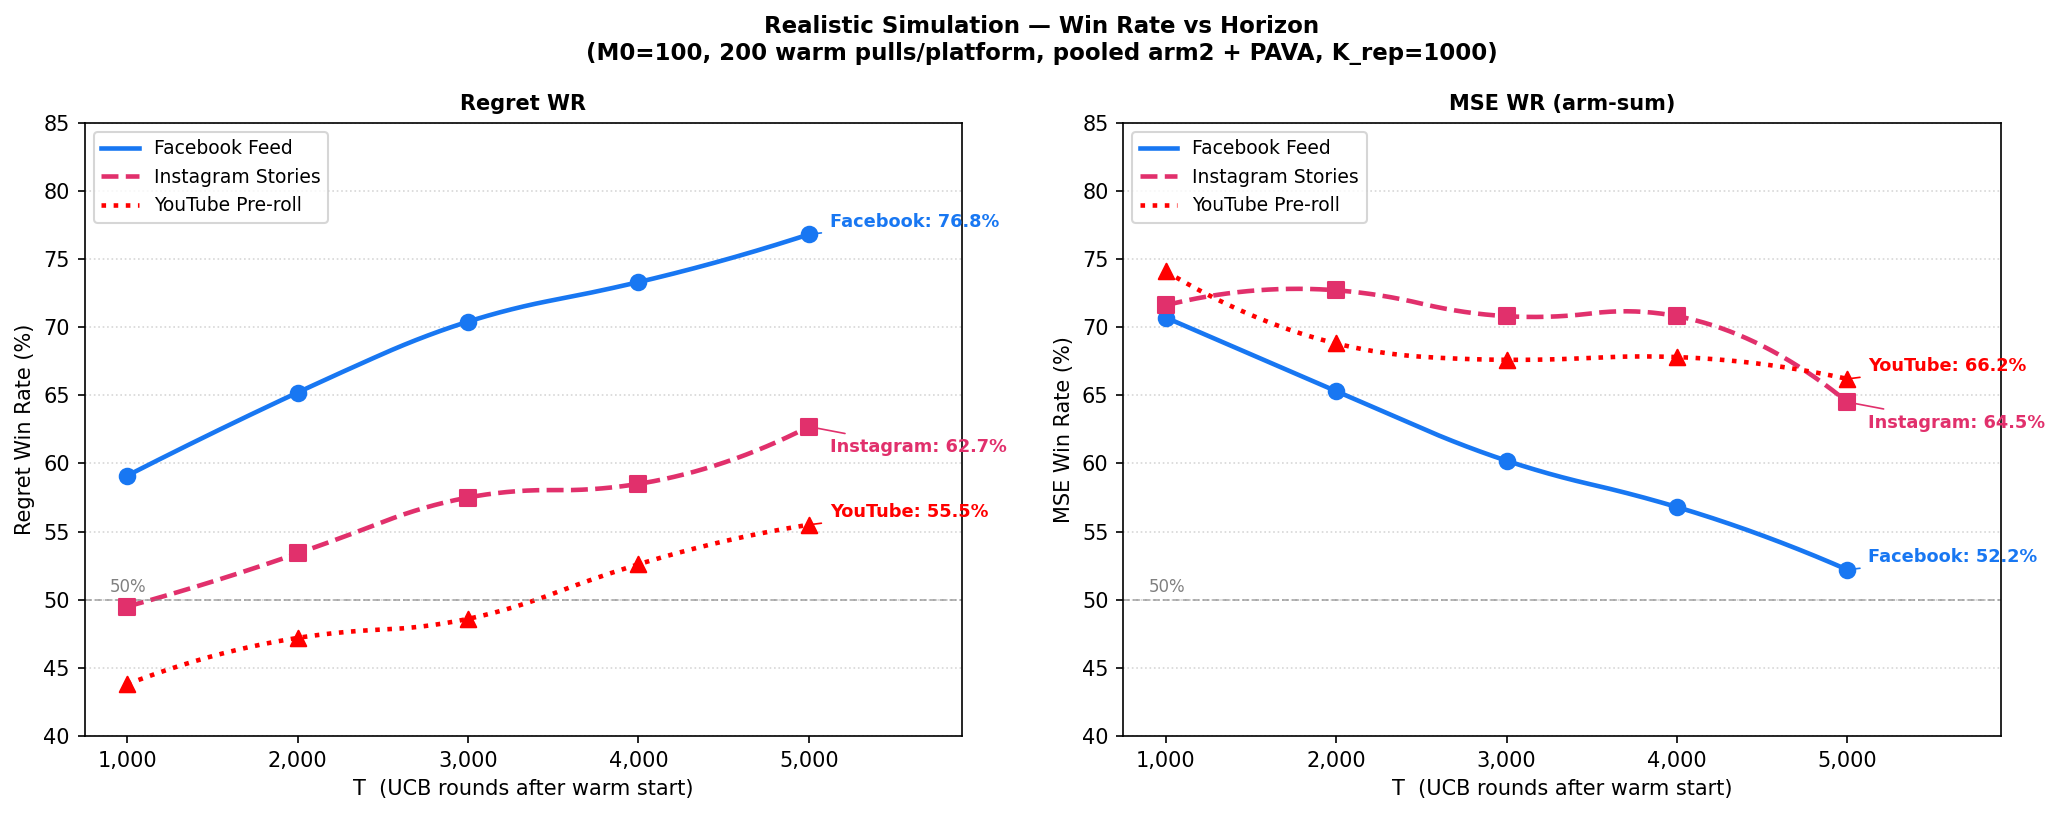

Saved → realistic_horizon_sweep.png


In [10]:
colors_p  = [p['color'] for p in PLATFORMS]
names_p   = [p['name']  for p in PLATFORMS]
linestyle = ['-', '--', ':']
markers   = ['o', 's', '^']
ANNOT_OFFSETS = [6, -10, 6]

T_arr  = np.array(T_vals, dtype=float)
T_fine = np.linspace(T_arr[0], T_arr[-1], 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    'Realistic Simulation — Win Rate vs Horizon\n'
    '(M0=100, 200 warm pulls/platform, pooled arm2 + PAVA, K_rep=1000)',
    fontsize=11, fontweight='bold'
)

# rwr shape = (n_cp, K)    → non-anchor cols are [:, 1:]
# mwr shape = (n_cp, K-1)  → all cols are [:, 0:]
panels = [
    (rwr[:, 1:], 'Regret Win Rate (%)', 'Regret WR'),   # skip anchor col 0
    (mwr,        'MSE Win Rate (%)',    'MSE WR (arm-sum)'),
]

for ax, (wr_data, ylabel, title) in zip(axes, panels):
    for j, i in enumerate(range(1, K)):          # j=0,1,2  i=1,2,3
        y   = wr_data[:, j]                       # both arrays now j-indexed correctly
        col = colors_p[i]
        lbl = names_p[i]

        spl    = make_interp_spline(T_arr, y, k=2)
        y_fine = np.clip(spl(T_fine), 0, 100)

        ax.plot(T_fine, y_fine, color=col, linewidth=2.2,
                linestyle=linestyle[j], label=lbl)
        ax.scatter(T_arr, y, color=col, s=55, marker=markers[j], zorder=5)
        ax.annotate(
            f'{lbl.split()[0]}: {y[-1]:.1f}%',
            xy=(T_arr[-1], y[-1]),
            xytext=(10, ANNOT_OFFSETS[j]),
            textcoords='offset points',
            fontsize=8.5, color=col, va='center', fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=col, lw=0.8)
        )

    ax.axhline(50, color='gray', linestyle='--', linewidth=0.9, alpha=0.6)
    ax.text(T_arr[0] - 100, 50.6, '50%', fontsize=8, color='gray')
    ax.set_xlabel('T  (UCB rounds after warm start)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(T_vals)
    ax.set_xticklabels([f'{t:,}' for t in T_vals])
    ax.set_xlim(T_arr[0] - 250, T_arr[-1] + 900)
    ax.set_ylim(40, 85)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
out_path = 'realistic_horizon_sweep.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
display(Image(out_path))
print(f'Saved → {out_path}')